### This notebook includes code for executing SGBM, LSMC and LSMCB along with the tests to compare the methods. This is a research comparison and this is not production level code.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from queue import Queue
from scipy.special import comb
from scipy.stats import norm, t
import time
np.random.seed(seed = 1222)

# Background Functions

In [2]:
def GBM(S0, r, vol, time_steps, num_paths, T, q=0, seed = None):
    '''
    Produces the geometric brownian motion paths of the stock. Returns in the shape (num_paths x (time_steps + 1))
    
    Inputs:
    
    S0: the initial stock price
    r: the interest rate
    vol: volatility of the stock
    time_steps: number of time steps
    num_paths: number of paths generated
    T: time to expiry
    q: dividend factor (set to 0 initially)
    seed: seed to ensure the tests are reproducable

    Output:

    paths which is a (num_paths x (time_steps + 1)) matrix
    '''
    np.random.seed(seed)
    dt    = T / time_steps
    drift = (r - q - 0.5 * vol**2) * dt
    vol_dt   = vol * np.sqrt(dt)

    Z         = np.random.standard_normal((time_steps, num_paths))
    log_steps = drift + vol_dt * Z                       
    log_paths = np.vstack([np.zeros(num_paths),        
                           np.cumsum(log_steps, axis=0)])
    return S0 * np.exp(log_paths)

In [42]:
#The basis functions used for both LSMC and SGBM are the first 4 polynomial factors

def basis(x, n):
    '''
    The basis fuinctions used for the three methods. We use polynomial powers.

    Input:
    
    x: the stock price
    n: the polynomial value of the stock

    output:
    
    the return of the n^th basis
    '''
    return x**n

def basis_cond_exp_poly_S(x, n, vol, dt, r):
    '''
    This is the analytic expected conditioning of a polynomial basis with the input being S. This function is used as an intermediary step in the true
    Basis conditoning function.

    Input:
    
    x: the current stock price
    n: the basis function
    vol: the volatility of underlying
    dt: time step difference
    r: interest rate

    Output:
    
    The value of conditioning for each basis function with S as the input
    '''
    return (x * np.exp(r* dt + 0.5 * (n-1) * dt * vol**2))**n

def basis_cond_exp(x, n, K, vol, dt, r, option_type):
    '''
    The analytic expected conditioning of a polynomial basis when the input is S-K. This is the function used in SGBM.

    Input:
    
    x: the current stock price
    n: the basis function
    K: the strike of the option
    vol: the volatility of underlying
    dt: time step difference
    r: interest rate
    option_type: 'c' or 'p' depending on whether the option is a call or put respectively.

    Output:
    
    The value of conditioning for each basis function with S-K as the input
    '''
    tot = 0
    for i in range(n+1):
            tot += ((-K)**(n-i)) * comb(n,i) * basis_cond_exp_poly_S(x, i, vol, dt, r)
    if option_type == 'c':
        return tot
    else:
        tot *= (-1)**n
        return tot

def bifurcation(S_prev, bundle_mapping, num_iter):
    '''
    The goal is to use the bifurcation method from the paper (which calls this method Recursive bifurcation of reduced state space).
    
    Input:
    
    S_prev: all paths from the previous path (current when using LSMC)
    bundle_mapping: a function that returns the payoff without the 0 flooring used when bifurcating
    num_itr: number of iterations for bifurcation, there are 2**num_itr bundles

    Output:
    
    final_output: this is a (num_paths x 2) matrix which indicates the bundled set number (0 through 2**num_itr-1) sorted and the second column includes
                  the index of each path that is part of each set.
    '''
    mapping = bundle_mapping(S_prev)
    collected_vals = np.arange(len(S_prev), dtype = int)
    q = Queue()
    q.put(collected_vals)
    for i in range(2**num_iter - 1):
        curr_vals = q.get()
        if len(curr_vals)>0:
            mean_val = mapping[curr_vals].mean()
            q.put(curr_vals[mapping[curr_vals] < mean_val])
            q.put(curr_vals[mapping[curr_vals] >= mean_val])

    final_output = []
    while q.empty() != True:
        curr_vals = q.get()
        if len(curr_vals) != 0:
            final_output.append(curr_vals)

    return final_output

# The Three Methods

Below are the functions that run the three methods we are comparing in this project.

In [43]:
def LSMC(paths, payoff, num_basis, T, r):
    '''
    This function produces a slightly varied LSMC that you would use for CVA purposes to measure the continuation values. 
    The main difference is that this uses OTM paths as well as ITM paths.
    
    Input:
    
    paths: paths simualted from some process (GBM in our case)
    payoff: The payoff to be used inside the basis functions
    num_basis: the number of basis functions used
    T: time to expiry in years
    r: discount rate
    
    Output:
    
    [0]: continuation_vals which contains the value of holding the option at each time step i.
    [1]: exercise time which is the vector of the times in which the option exercises for each path.
    [2]: a (time_steps-1 x num_paths) array with binary inputs, (1) for exercise at timestep i and (0) for no exercise, 
         this vector does not include the final time step since exercise is forced then
    '''
    intrinsic = np.maximum(payoff(paths),0)
    terminal_val = intrinsic[-1].copy()
    time_steps, num_paths = paths.shape
    exercise_time = np.ones(num_paths)*(time_steps-1) #This holds the time at which each option is exercised (at the start this is the final date of the option)
    continuation_vals = np.zeros((time_steps-1,num_paths))
    dt = T/(time_steps-1)
    ex_time = np.zeros((time_steps-1,num_paths))
    
    for i in range(time_steps - 2, -1, -1):
        curr_stocks = paths[i]
        Y = np.exp(-r * dt * (exercise_time - i)) * terminal_val
        X = np.empty((num_paths,0))
        for j in range(num_basis):
            X = np.column_stack((X, basis(payoff(curr_stocks),j)))
        params, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
        Val = np.maximum(X @ params, 0)
        continuation_vals[i,:] = Val
        ex_now = (Val <= intrinsic[i]) & (intrinsic[i] >0)
        terminal_val[ex_now] = intrinsic[i][ex_now]
        exercise_time[ex_now] = i
        ex_time[i] = ex_now
    
    return (continuation_vals, exercise_time, ex_time)

In [44]:
def SGBM(paths, bundle_mapping, option_type, num_basis, T, K, num_itr, vol, r):
    '''
    This function recreates SGBM from Jain and Oosterlee. The core loop of this function is going backwards each time step, bifurcating and then fitting
    a basis expansion to each future step and then using analytic conditioning to get the continuation value at each time step. 
    
    Input:
    
    paths: paths simualted from some process (GBM in our case)
    bundle_mapping: a function that returns the payoff without the 0 flooring used when bifurcating
    option_type: 'c' or 'p' depending on whether the option is a call or put respectively
    num_basis: number of basis functions used 
    T: time to expiry in years
    K: the strike of the option
    num_itr: number of iterations for bifurcation, there are 2**num_itr bundles
    vol: the volatility of the stock
    r: discount rate

    Output:
    [0]: coninuation values of the option at each time step
    [1]: the mean of the value function
    [2]: a (time_steps-1 x num_paths) array with binary inputs, (1) for exercise at timestep i and (0) for no exeercise, 
         this vector does not include the final time step since exercise is forced then
    '''
    time_steps, num_paths = paths.shape[0], paths.shape[1]
    value_func = np.maximum(bundle_mapping(paths[-1]),0)
    continuation_vals = np.zeros((time_steps-1,num_paths))
    dt = T/(time_steps-1)
    discount = np.exp(-r * dt)
    ex_time = np.zeros((time_steps-1, num_paths))
    
    for i in range(time_steps-1, 0, -1):
        S_curr = paths[i]
        S_prev = paths[i-1]
        bifurc_indx = bifurcation(S_prev, bundle_mapping, num_itr) #bundling occurs on the previous path that needs to estimate the future payoffs
        
        for curr_indx in bifurc_indx:

            if len(curr_indx) == 0:
                continue

            X = np.empty((len(curr_indx),0))
            X_cond_exp = np.empty((len(curr_indx),0))
            for k in range(num_basis):
                X = np.column_stack((X, basis(bundle_mapping(S_curr[curr_indx]),k)))
                X_cond_exp = np.column_stack((X_cond_exp, basis_cond_exp(S_prev[curr_indx], k, K, vol, dt, r, option_type)))
    
            params,_,_,_ = np.linalg.lstsq(X, value_func[curr_indx],rcond = None)
            
            cont_value = discount * (X_cond_exp @ params)
    
            continuation_vals[i-1, curr_indx] = cont_value
            intr = np.maximum(bundle_mapping(S_prev[curr_indx]),0)
            ex_now = (cont_value <= intr) & (intr > 0)
            ex_time[i-1, curr_indx] = ex_now
            value_func[curr_indx] = np.maximum(cont_value, np.maximum(bundle_mapping(S_prev[curr_indx]),0))

    return (continuation_vals, np.mean(value_func), ex_time)

In [45]:
##This is a variant of LSMC that incorprates bundling too.
def LSMCB(paths, bundle_mapping, num_basis, T, K, r, num_itr):
    '''
    This is the LSMC method that includes bundling (which is part of SGBM). The function is otherwise identical to LSMC
    
    Input:
    
    paths: paths simualted from some process (GBM in our case)
    bundle_mapping: a function that returns the payoff without the 0 flooring used when bifurcations
    num_basis: number of basis functions used
    T: time to expiry in years
    K: strike of the options
    r: discount rate
    num_itr: number of iterations for bifurcation, there are 2**num_itr bundles
    
    Output:
    
    [0]: continuation_vals which contains the value of holding the option at each time step i.
    [1]: exercise time which is the vector of the times in which the option exercises for each path.
    [2]: a (time_steps-1 x num_paths) array with binary inputs, (1) for exercise at timestep i and (0) for no exeercise, 
         this vector does not include the final time step since exercise is forced then
    '''
    intrinsic = np.maximum(bundle_mapping(paths),0)
    terminal_val = intrinsic[-1].copy()
    time_steps, num_paths = paths.shape
    exercise_time = np.ones(num_paths)*(time_steps-1)
    continuation_vals = np.zeros((time_steps-1,num_paths))
    dt = T/(time_steps-1)
    ex_time = np.zeros((time_steps-1, num_paths))
    
    for i in range(time_steps - 2, -1, -1):
        curr_stocks = paths[i]
        curr_intr = intrinsic[i]
        bifurc_indx = bifurcation(curr_stocks, bundle_mapping, num_itr)
        for curr_indx in bifurc_indx:

            if len(curr_indx) == 0:
                continue
                
            Y = np.exp(-r * dt * (exercise_time[curr_indx] - i)) * terminal_val[curr_indx]

            X = np.empty((len(curr_indx),0))
            for k in range(num_basis):
                X = np.column_stack((X, basis(bundle_mapping(curr_stocks[curr_indx]),k)))

            params, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
            Val = np.maximum(X @ params, 0)
            continuation_vals[i,curr_indx] = Val
            ex_now = (Val <= intrinsic[i][curr_indx]) & (intrinsic[i][curr_indx] > 0)
            ex_time[i,curr_indx] = ex_now
            idx = curr_indx[ex_now]
            terminal_val[idx] = intrinsic[i][idx]
            exercise_time[idx] = i
    return (continuation_vals, exercise_time, ex_time)

### This function is used to produce the outputs of the methods into EPE values that can then be used for CVA purposes.

In [46]:
def EPE(cont_vals, intr, ex_decision):
    '''
    This function is used to convert the continuation values, exercise decisions and intrinsic values into PE and then return the EPE. 
    This is detailed in the read me.

    Input:

    cont_vals: continuation values of the option at each time step and each path
    intr: the intrinsic value of the option at each time step and each path
    ex_decisions: the exercise decision for each time step and each path, a 1 represents exercise at a specific time step and a 0 means do nothing.

    Output:
    
    EPE: The final EPE with size time_steps that measures the Expected positive exposure at each time step.
    
    '''
    
    PE = np.where(ex_decision, intr[:-1], cont_vals)
    PE = np.where((np.cumsum(np.maximum.accumulate(ex_decision, axis = 0),axis = 0) > 1), 0.0, PE)
    return np.mean(PE, axis = 1)

# Case 1: American Call Test

### We begin by testing the methods on an American Call.

In [47]:
#Initial parameters
S0 = 100
r = 0.05
q = 0.0
vol = 0.1
time_steps = 50
num_paths = 100000
T = 1
K = 100
option_type = 'c'

def call(x):
    return x - K

real_val = 6.805 #the real value using B-S equations and using the fact that q=0 in our examples
ref = np.exp(r * np.arange(time_steps)/time_steps) * real_val #The reference value to compare with the EPE's computed

### This is the parameter grid search to uncover the best parameter choice for the methods.

In [48]:
simulations = 25

results_LSMC = np.zeros((7, simulations))
results_SGBM = np.zeros((7, 7, simulations))
results_LSMCB = np.zeros((7, 7, simulations))
seed = 1020

for j in range(simulations):
    paths = GBM(S0,r,vol,time_steps,num_paths,T,q,seed+j)
    intrinsic = np.maximum(call(paths),0)
    result_row_LSMC = []
    result_row_LSMCB = []
    result_row_SGBM = []

    for num_basis in range(1,8):
        for num_bifurc in range(1,8):
            cont_vals, _, ex = SGBM(paths,call,option_type,num_basis,T,K,num_bifurc, vol, r)
            epe_m = EPE(cont_vals, intrinsic, ex)
            results_SGBM[num_bifurc-1,num_basis-1,j] = np.sqrt(np.mean((epe_m-ref)**2))
            cont_vals, _, ex= LSMCB(paths,call,num_basis,T,K,r,num_bifurc)
            epe_m = EPE(cont_vals, intrinsic, ex)
            results_LSMCB[num_bifurc-1,num_basis-1,j] = np.sqrt(np.mean((epe_m-ref)**2))
        cont_vals, _, ex= LSMC(paths,call,num_basis,T,r)
        epe_m = EPE(cont_vals, intrinsic, ex)
        results_LSMC[num_basis-1,j] = np.sqrt(np.mean((epe_m-ref)**2))

In [49]:
results_SGBM.mean(axis = 2)

array([[7.13128001, 0.59185762, 0.19883521, 0.07284433, 0.04507539,
        0.04315993, 0.03008803],
       [3.76787735, 0.10957212, 0.02708391, 0.01977122, 0.01737837,
        0.01679548, 0.01660874],
       [1.83859392, 0.02607562, 0.0170368 , 0.01662964, 0.01647537,
        0.01645106, 0.01644873],
       [0.98719373, 0.01694307, 0.01655866, 0.01648391, 0.01645117,
        0.0164524 , 0.01644125],
       [0.55626291, 0.01657283, 0.01652881, 0.01648102, 0.0164607 ,
        0.01643621, 0.01641993],
       [0.27299973, 0.0165567 , 0.01651819, 0.01648431, 0.01645209,
        0.01643347, 0.01642063],
       [0.12151356, 0.01653071, 0.01651869, 0.01648082, 0.01644941,
        0.01642251, 0.01642311]])

In [50]:
results_LSMCB.mean(axis = 2)

array([[5.28377541, 0.58173466, 0.15184683, 0.02750843, 0.02047323,
        0.02139501, 0.02150507],
       [5.14113563, 0.06370684, 0.02029406, 0.02054433, 0.02150504,
        0.0223353 , 0.02270274],
       [4.51609007, 0.01934422, 0.02046086, 0.02164027, 0.02284897,
        0.02361441, 0.02317491],
       [3.60855078, 0.020389  , 0.02176618, 0.02360975, 0.02682647,
        0.02859639, 0.02878345],
       [2.27341529, 0.02219444, 0.02916953, 0.04060949, 0.05907011,
        0.0636699 , 0.06510942],
       [0.99294842, 0.03702881, 0.0762783 , 0.1258561 , 0.17615308,
        0.18011844, 0.17976778],
       [0.41439781, 0.11359279, 0.22660524, 0.32669628, 0.35891283,
        0.36349314, 0.36252879]])

In [51]:
results_LSMC.mean(axis = 1)

array([4.05421448, 2.20361664, 2.4090959 , 1.17924039, 1.29803496,
       0.82159285, 0.60116116])

### We now run the methods on a single simulation to observe how the methods perform and where they differ.

In [52]:
seed = 575
paths = GBM(S0,r,vol,time_steps,num_paths,T,q,seed)
intrinsic = np.maximum(call(paths),0)

num_basis = 7
cont_vals_lsmc, _, ex_lsmc = LSMC(paths,call,num_basis,T,r)
lsmc_epe = EPE(cont_vals_lsmc, intrinsic , ex_lsmc)

num_basis = 7
num_bifurc = 5
cont_vals_sgbm, _, ex_sgbm = SGBM(paths,call,option_type,num_basis,T,K,num_bifurc, vol, r)
sgbm_epe = EPE(cont_vals_sgbm, intrinsic , ex_sgbm)

num_basis = 2
num_bifurc = 3
cont_vals_lsmcb, _, ex_lsmcb = LSMCB(paths,call,num_basis,T,K,r,num_bifurc)
lsmcb_epe = EPE(cont_vals_lsmcb, intrinsic , ex_lsmcb)

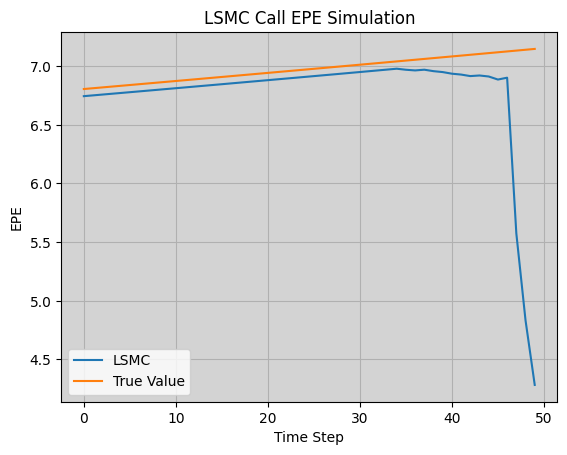

In [53]:
fig, ax = plt.subplots()
ref = np.exp(r * np.arange(time_steps)/time_steps) * real_val

ax.plot(np.arange(time_steps), lsmc_epe, label="LSMC")
ax.plot(np.arange(time_steps), ref, label="True Value")

ax.set_facecolor("lightgray")
ax.set_xlabel("Time Step")
ax.set_ylabel("EPE")
ax.set_title("LSMC Call EPE Simulation")

ax.legend(loc = 'lower left')
ax.grid(True)

plt.savefig("LSMC_Call_EPE_Graph.svg")
plt.show()

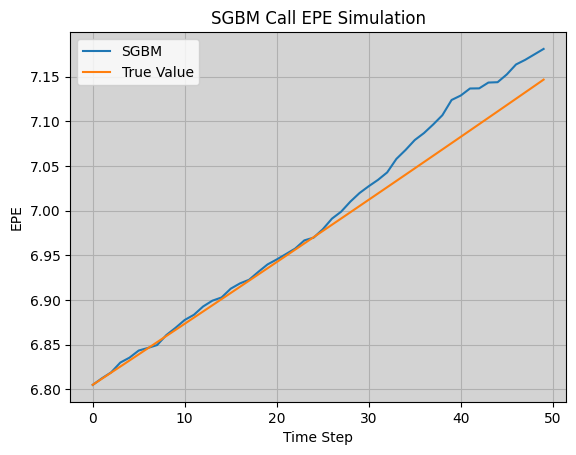

In [54]:
fig, ax = plt.subplots()
ax.plot(np.arange(time_steps), sgbm_epe, label="SGBM")
ax.plot(np.arange(time_steps), ref, label="True Value")

ax.set_facecolor("lightgray")
ax.set_xlabel("Time Step")
ax.set_ylabel("EPE")
ax.set_title("SGBM Call EPE Simulation")

ax.legend(loc = 'upper left')
ax.grid(True)

plt.savefig("SGBM_Call_EPE_Graph.svg")
plt.show()

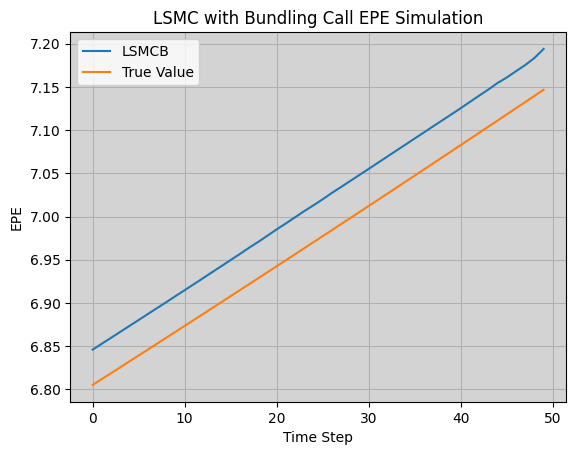

In [55]:
fig, ax = plt.subplots()
ax.plot(np.arange(time_steps), lsmcb_epe, label="LSMCB")
ax.plot(np.arange(time_steps), ref, label="True Value")

ax.set_facecolor("lightgray")
ax.set_xlabel("Time Step")
ax.set_ylabel("EPE")
ax.set_title("LSMC with Bundling Call EPE Simulation")

ax.legend(loc = 'upper left') 
ax.grid(True)

plt.savefig("LSMCB_Call_EPE_Graph.svg")
plt.show()

In [56]:
ex_true = np.zeros((time_steps, num_paths))
print("The different methods may exercise when they should not (false postives) or decide to continue and not exercise when they should (False negatives), we now report the figures for these results")
print(f"LSMC had {np.sum((ex_lsmc - ex_true) == 1)} False Positives and {np.sum((ex_lsmc - ex_true) == -1)} False Negatives")
print(f"SGBM had {np.sum((ex_sgbm - ex_true) == 1)} False Positives and {np.sum((ex_sgbm - ex_true) == -1)} False Negatives")
print(f"LSMCB had {np.sum((ex_lsmcb - ex_true) == 1)} False Positives and {np.sum((ex_lsmcb - ex_true) == -1)} False Negatives")

The different methods may exercise when they should not (false postives) or decide to continue and not exercise when they should (False negatives), we now report the figures for these results
LSMC had 95174 False Positives and 0 False Negatives
SGBM had 0 False Positives and 0 False Negatives
LSMCB had 494 False Positives and 0 False Negatives


In [57]:
print("We can also test if the methods exercise at the right time")
print(f"LSMC exercised at the right time {100*np.sum((np.argmax(ex_lsmc, axis=0) - np.argmax(ex_true, axis = 0)) == 0)/(num_paths)}% of the time")
print(f"SGBM exercised at the right time {100*np.sum((np.argmax(ex_sgbm, axis=0) - np.argmax(ex_true, axis = 0)) == 0)/(num_paths)}% of the time")
print(f"LSMCB exercised at the right time {100*np.sum((np.argmax(ex_lsmcb, axis=0) - np.argmax(ex_true, axis = 0)) == 0)/(num_paths)}% of the time")

We can also test if the methods exercise at the right time
LSMC exercised at the right time 65.831% of the time
SGBM exercised at the right time 100.0% of the time
LSMCB exercised at the right time 99.506% of the time


In [58]:
dt = T/time_steps
disc = np.exp(-r * dt)
prob_default_step = 0.02 * dt #Flat 2% chance of defaulting in a year, assumed to be uniform
real_CVA = np.sum(disc * prob_default_step * ref)
LSMC_CVA = np.sum(disc * prob_default_step * lsmc_epe)
SGBM_CVA = np.sum(disc * prob_default_step * sgbm_epe)
LSMC_Bundling_CVA = np.sum(disc * prob_default_step * lsmcb_epe)

In [59]:
print(f"The true value of this CVA calculation should be {np.round(real_CVA,4)}")
print(f"LSMC estimates the value as {np.round(LSMC_CVA,4)} with an absolute error of {np.round(100*np.abs(real_CVA - LSMC_CVA)/LSMC_CVA,4)}%")
print(f"SGBM estimates the value as {np.round(SGBM_CVA,4)} with an absolute error of {np.round(100*np.abs(real_CVA - SGBM_CVA)/SGBM_CVA,4)}%")
print(f"LSMCB estimates the value as {np.round(LSMC_Bundling_CVA,4)} with an absolute error of {np.round(100*np.abs(real_CVA - LSMC_Bundling_CVA)/LSMC_Bundling_CVA,4)}%")

The true value of this CVA calculation should be 0.1394
LSMC estimates the value as 0.1351 with an absolute error of 3.1715%
SGBM estimates the value as 0.1397 with an absolute error of 0.2206%
LSMCB estimates the value as 0.1402 with an absolute error of 0.6048%


### We now run the same test 100 times to observe more concrete results and see how the methods differ in their outputs.

In [60]:
methods = {
    "LSMC":  lambda p: LSMC(p, call, 7, T, r),
    "LSMCB": lambda p: LSMCB(p, call, 2, T, K, r, 3),
    "SGBM":  lambda p: SGBM(p, call, option_type, 7, T, K, 5, vol, r),
}
num_replications = 100
real_CVA = np.sum(disc * prob_default_step * ref)
rows = []
for j in range(num_replications):
    paths     = GBM(S0, r, vol, time_steps, num_paths, T, seed=1232+j)
    intrinsic = np.maximum(call(paths), 0)
    row = {"rep": j}
    for name, fn in methods.items():
        t0 = time.perf_counter()
        cont_vals, _, ex = fn(paths)
        secs = time.perf_counter() - t0
        epe = EPE(cont_vals, intrinsic, ex)
        cva = np.sum(disc * prob_default_step * epe)
        row |= {f"{name}_RMSE":      np.sqrt(np.mean((epe - ref)**2)),
                f"{name}_Bias":      np.mean(epe - ref),
                f"{name}_Time":      secs,
                f"{name}_CVA_Error": 100 * abs(cva - real_CVA) / real_CVA}
    rows.append(row)

results = pd.DataFrame(rows)

In [61]:
results.mean(axis = 0)

rep                49.500000
LSMC_RMSE           0.600429
LSMC_Bias          -0.255921
LSMC_Time           0.825329
LSMC_CVA_Error      3.669380
LSMCB_RMSE          0.019460
LSMCB_Bias         -0.000602
LSMCB_Time          0.329542
LSMCB_CVA_Error     0.275810
SGBM_RMSE           0.015776
SGBM_Bias          -0.000075
SGBM_Time           1.897226
SGBM_CVA_Error      0.168634
dtype: float64

In [62]:
results.std(axis = 0)

rep                29.011492
LSMC_RMSE           0.043054
LSMC_Bias           0.034439
LSMC_Time           0.012887
LSMC_CVA_Error      0.493781
LSMCB_RMSE          0.013922
LSMCB_Bias          0.023908
LSMCB_Time          0.019273
LSMCB_CVA_Error     0.201858
SGBM_RMSE           0.008145
SGBM_Bias           0.014428
SGBM_Time           0.107234
SGBM_CVA_Error      0.118611
dtype: float64

### Below we have added confidence levels for the difference between methods, the first figure is the lower bound, the second the mean and the third the upper bound for a 95% CI.

In [63]:
#The difference between LSMCB and SGBM's CVA error
std_for_test = (results['SGBM_CVA_Error'] - results['LSMCB_CVA_Error']).std(ddof = 1)/np.sqrt(num_replications)
mean_for_test = np.mean(results['LSMCB_CVA_Error'] - results['SGBM_CVA_Error'])
print(mean_for_test + t.ppf(0.025,num_replications-1) * std_for_test)
print(mean_for_test)
print(mean_for_test + t.ppf(0.975,num_replications-1) * std_for_test)

0.07766116448367251
0.10717581782709913
0.13669047117052574


In [64]:
#The difference between LSMC and LSMCB's CVA error
std_for_test = (results['LSMCB_CVA_Error'] - results['LSMC_CVA_Error']).std(ddof = 1)/np.sqrt(num_replications)
mean_for_test = np.mean(results['LSMC_CVA_Error'] - results['LSMCB_CVA_Error'])
print(mean_for_test + t.ppf(0.025,num_replications-1) * std_for_test)
print(mean_for_test)
print(mean_for_test + t.ppf(0.975,num_replications-1) * std_for_test)

3.2955974090644906
3.393570646235583
3.491543883406675


In [65]:
#The difference between LSMC and SGBM's CVA error
std_for_test = (results['SGBM_CVA_Error'] - results['LSMC_CVA_Error']).std(ddof = 1)/np.sqrt(num_replications)
mean_for_test = np.mean(results['LSMC_CVA_Error'] - results['SGBM_CVA_Error'])
print(mean_for_test + t.ppf(0.025,num_replications-1) * std_for_test)
print(mean_for_test)
print(mean_for_test + t.ppf(0.975,num_replications-1) * std_for_test)

3.4017191177339456
3.500746464062681
3.5997738103914165


In [66]:
#The difference between LSMCB and SGBM's RMSE
std_for_test = (results['SGBM_RMSE'] - results['LSMCB_RMSE']).std(ddof = 1)/np.sqrt(num_replications)
mean_for_test = np.mean(results['LSMCB_RMSE'] - results['SGBM_RMSE'])
print(mean_for_test + t.ppf(0.025,num_replications-1) * std_for_test)
print(mean_for_test)
print(mean_for_test + t.ppf(0.975,num_replications-1) * std_for_test)

0.0018307592974605772
0.0036837049419624506
0.005536650586464324


In [67]:
#The difference between LSMC and LSMCB's RMSE
std_for_test = (results['LSMCB_RMSE'] - results['LSMC_RMSE']).std(ddof = 1)/np.sqrt(num_replications)
mean_for_test = np.mean(results['LSMC_RMSE'] - results['LSMCB_RMSE'])
print(mean_for_test + t.ppf(0.025,num_replications-1) * std_for_test)
print(mean_for_test)
print(mean_for_test + t.ppf(0.975,num_replications-1) * std_for_test)

0.5721473945966278
0.5809695681128962
0.5897917416291647


In [68]:
#The difference between LSMC and SGBM's RMSE
std_for_test = (results['SGBM_RMSE'] - results['LSMC_RMSE']).std(ddof = 1)/np.sqrt(num_replications)
mean_for_test = np.mean(results['LSMC_RMSE'] - results['SGBM_RMSE'])
print(mean_for_test + t.ppf(0.025,num_replications-1) * std_for_test)
print(mean_for_test)
print(mean_for_test + t.ppf(0.975,num_replications-1) * std_for_test)

0.5759440730756498
0.5846532730548587
0.5933624730340676


# Case 2: American Put Test

### We now consider the American Put test. For this method we use the CRR to produce a benchmark reference to compare the methods.

In [69]:
def crr(S0, K, r, vol, T, N, payoff, ex_times, q = 0):
    '''
    This function calculates the cox-ross-rubinstien continuation values of an option (in our case for the reference of put options).

    Input:
    
    S0: the intial stock price at time 0
    K: the strike price of the option
    r: the interest rate
    vol: the volatility of the option
    T: time of expiry for the option
    N: the number of time steps, each up or down factor gets multiplied at each step
    payoff: 'c' or 'p' depending on whether the option is a call or put respectively
    ex_times: the timesteps where exercising is possible, assumed to only include time steps that are possible
    q: the dividend factor

    Output:
    
    continuation: continuation values of the option over each time step
    crr_surface: dictionary with the potential stock prices at each time step and their respective continuation values
    EPE: The EPE graph used as a reference for the methods
    '''
    dt = T / N
    u = np.exp(vol*np.sqrt(dt)) 
    d = np.exp(-vol*np.sqrt(dt))
    p = (np.exp((r-q)*dt) - d) / (u - d)
    
    j = np.arange(N+1)
    S = S0 * u**j * d**(N-j)
    
    if payoff == 'c':
        V = np.maximum(S-K, 0.0)
    else:
        V = np.maximum(K-S, 0.0)
    
    continuation = np.ones(len(ex_times))
    crr_surface = {}
    ex_set = set(ex_times)
    k = 0
    
    for i in range(N-1, -1, -1):
        j = np.arange(i+1)
        S = S0 * u**j * d**(i-j)
        prob_weight = comb(i,j) * (p**j) * (1-p)**(i-j)
        cont = np.exp(-r*dt) * (p*V[1:i+2] + (1-p)*V[0:i+1])
        
        if payoff == 'c':
            intr = np.maximum(S-K, 0.0)
        else:
            intr = np.maximum(K-S, 0.0)
        ex_now = (cont < intr) & (intr > 0)
        if i in ex_set:
            V = np.where(ex_now, intr, cont)#np.maximum(cont, intr)
            continuation[k] = np.sum(prob_weight * cont)
            k+=1
        else:
            V = cont
        crr_surface[i] = (S.copy(), cont.copy())

    j = 0
    prob = np.array([1.0])
    EPE = np.zeros(len(ex_times))
    
    for i in range(0, N):
        S, cont = crr_surface[i]
        cont = cont.copy()
        
        if i in ex_set:
            if payoff == 'c':
                intr = np.maximum(S-K, 0.0)
            else:
                intr = np.maximum(K-S, 0.0)
            
            ex = (cont < intr) & (intr > 0)
            cont[ex] = intr[ex]
            EPE[j] = np.sum(prob * cont)
            prob[ex] = 0.0
            j+=1

        new_prob = np.zeros(i+2)
        new_prob[:-1] += prob * (1-p)
        new_prob[1:] += prob * p
        prob = new_prob
        
    return continuation, crr_surface, EPE


### This cell includes the initial parameters along with code to generate the benchmark reference.

In [72]:
#Initial parameters
S0 = 100
r = 0.05
q = 0.0
vol = 0.1
time_steps = 50
num_paths = 100000
T = 1
K = 100
option_type = 'p'
crr_steps  = 1000
seed = 5009
paths = GBM(S0,r,vol,time_steps,num_paths,T,q,seed)

def put(x):
    return K - x

ex_times = np.array([round(crr_steps * m / time_steps) for m in range(time_steps)], dtype=int)
ref_steps ,crr_results, epe = crr(S0, K, r, vol, T, crr_steps, 'p',ex_times,q=0.0)
true_cont = np.zeros((time_steps, num_paths))

for m, step in enumerate(ex_times):
    stocks, cont = crr_results[step]
    true_cont[m] = np.interp(paths[m], stocks, cont)

intr = np.maximum(0, K - paths[:time_steps])
ex_true = np.cumsum((intr > true_cont) & (intr > 0), axis=0) > 0


### This is the parameter grid search to uncover the best parameter choice for the methods.

In [73]:
simulations = 25
seed = 10001

results_LSMC = np.zeros((7, simulations))
results_SGBM = np.zeros((7, 7, simulations))
results_LSMCB = np.zeros((7, 7, simulations))


for j in range(simulations):
    paths = GBM(S0,r,vol,time_steps,num_paths,T,q,seed+j)
    intrinsic = np.maximum(put(paths),0)
    result_row_LSMC = []
    result_row_LSMCB = []
    result_row_SGBM = []

    for num_basis in range(1,8):
        for num_bifurc in range(1,8):
            cont_vals, _, ex_sgbm = SGBM(paths,put,option_type,num_basis,T,K,num_bifurc, vol, r)
            SGBM_EPE = EPE(cont_vals, intrinsic, ex_sgbm)
            results_SGBM[num_bifurc-1,num_basis-1,j] = np.sqrt(np.mean((epe - SGBM_EPE)**2))
            cont_vals, _, ex_lsmcb= LSMCB(paths,put,num_basis,T,K,r,num_bifurc)
            LSMCB_EPE = EPE(cont_vals, intrinsic, ex_lsmcb)
            results_LSMCB[num_bifurc-1,num_basis-1,j] = np.sqrt(np.mean((epe - LSMCB_EPE)**2))
        cont_vals, _, ex_lsmc= LSMC(paths,put,num_basis,T,r)
        LSMC_EPE = EPE(cont_vals, intrinsic, ex_lsmc)
        results_LSMC[num_basis-1,j] = np.sqrt(np.mean((epe - LSMC_EPE)**2))

In [74]:
results_SGBM.mean(axis = 2)

array([[6.08981774, 1.29069336, 0.33693975, 0.19761137, 0.13364267,
        0.08719326, 0.0563081 ],
       [3.53413607, 0.32465625, 0.09951159, 0.05648354, 0.02766053,
        0.01859187, 0.01571506],
       [1.92515414, 0.05051839, 0.017688  , 0.01391358, 0.01379444,
        0.01431658, 0.01458153],
       [0.94721065, 0.01360851, 0.01410273, 0.01457863, 0.01472128,
        0.01478383, 0.01478355],
       [0.37553832, 0.01535535, 0.01464984, 0.01470567, 0.01477044,
        0.01482191, 0.01475528],
       [0.14020968, 0.01571867, 0.01476798, 0.01469163, 0.0148275 ,
        0.01490124, 0.01468498],
       [0.05174969, 0.01701317, 0.01477828, 0.01458765, 0.01488702,
        0.01500176, 0.01457857]])

In [75]:
results_LSMCB.mean(axis = 2)

array([[0.34653535, 0.21798151, 0.05936845, 0.03247681, 0.03255847,
        0.02466975, 0.02493486],
       [0.59741498, 0.12771043, 0.07386491, 0.03520651, 0.02595603,
        0.02574852, 0.02495402],
       [0.41416946, 0.03821452, 0.02498866, 0.02599919, 0.0285526 ,
        0.0301749 , 0.03111102],
       [0.25954983, 0.02913215, 0.02940281, 0.03000213, 0.02925781,
        0.0300949 , 0.02912971],
       [0.15183352, 0.03061752, 0.02857712, 0.02750223, 0.02825976,
        0.02779656, 0.02815145],
       [0.07999534, 0.02855095, 0.02749519, 0.02659191, 0.02725383,
        0.02920305, 0.02839914],
       [0.04094037, 0.02690148, 0.02667841, 0.02769757, 0.0292547 ,
        0.03070757, 0.03014133]])

In [76]:
results_LSMC.mean(axis = 1)

array([0.52452737, 0.35635924, 0.20954626, 0.10317022, 0.09080974,
       0.05751963, 0.04494307])

### We now run the methods on a single simulation to observe how the methods perform and where they differ.

In [77]:
seed = 5009
paths = GBM(S0,r,vol,time_steps,num_paths,T,q,seed)
intrinsic = np.maximum(put(paths),0)



num_basis = 7
cont_vals_lsmc, _, ex_lsmc = LSMC(paths,put,num_basis,T,r)
lsmc_epe = EPE(cont_vals_lsmc,intrinsic,ex_lsmc)
num_basis = 2
num_bifurc = 4
cont_vals_sgbm, _, ex_sgbm = SGBM(paths,put,option_type,num_basis,T,K,num_bifurc, vol, r)
sgbm_epe = EPE(cont_vals_sgbm,intrinsic,ex_sgbm)
num_basis = 6
num_bifurc = 1
cont_vals_lsmcb, _, ex_lsmcb= LSMCB(paths,put,num_basis,T,K,r,num_bifurc)
lsmcb_epe = EPE(cont_vals_lsmcb,intrinsic,ex_lsmcb)

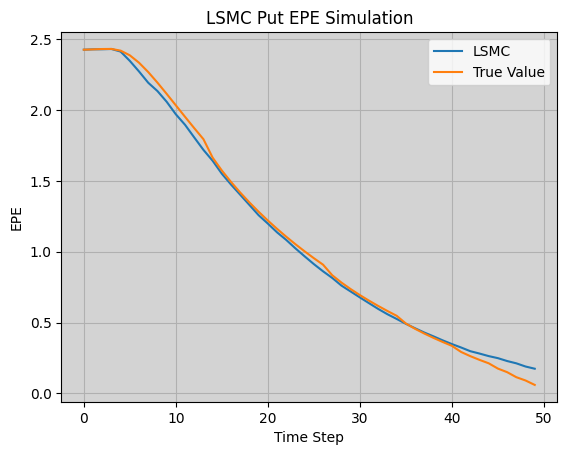

In [78]:
fig, ax = plt.subplots()

ax.plot(np.arange(time_steps), lsmc_epe, label="LSMC")
ax.plot(np.arange(time_steps), epe, label="True Value")

ax.set_facecolor("lightgray")
ax.set_xlabel("Time Step")
ax.set_ylabel("EPE")
ax.set_title("LSMC Put EPE Simulation")

ax.legend(loc = 'upper right')
ax.grid(True)

plt.savefig("LSMC_Put_EPE_Graph.svg")
plt.show()

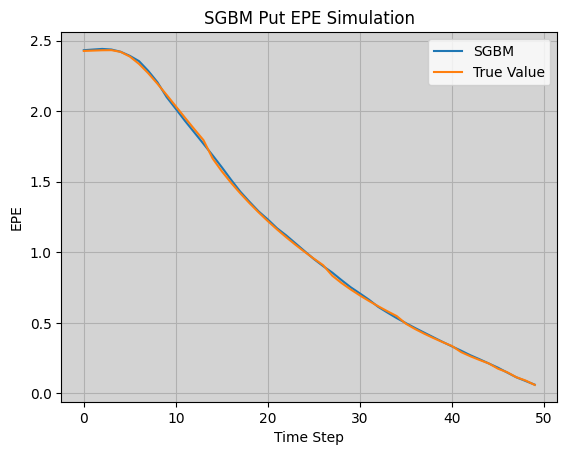

In [79]:
fig, ax = plt.subplots()
ax.plot(np.arange(time_steps), sgbm_epe, label="SGBM")
ax.plot(np.arange(time_steps), epe, label="True Value")

ax.set_facecolor("lightgray")
ax.set_xlabel("Time Step")
ax.set_ylabel("EPE")
ax.set_title("SGBM Put EPE Simulation")

ax.legend(loc = 'upper right')
ax.grid(True)

plt.savefig("SGBM_Put_EPE_Graph.svg")
plt.show()

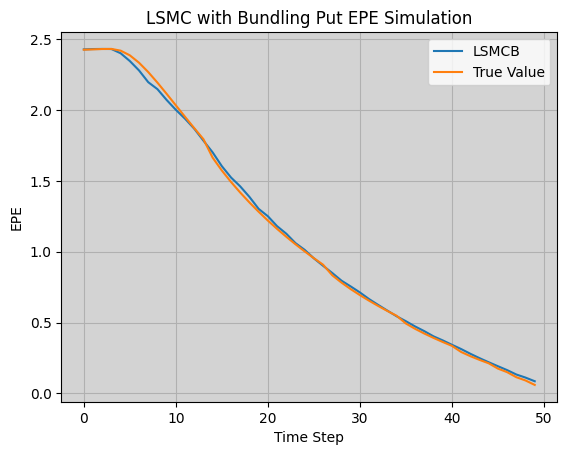

In [80]:
fig, ax = plt.subplots()
ax.plot(np.arange(time_steps), lsmcb_epe, label="LSMCB")
ax.plot(np.arange(time_steps), epe, label="True Value")

ax.set_facecolor("lightgray")
ax.set_xlabel("Time Step")
ax.set_ylabel("EPE")
ax.set_title("LSMC with Bundling Put EPE Simulation")

ax.legend(loc = 'upper right') 
ax.grid(True)

plt.savefig("LSMCB_Put_EPE_Graph.svg")
plt.show()

In [81]:
dt = T/time_steps
disc = np.exp(-r * dt)
prob_default_step = 0.02 * dt #Flat 2% chance of defaulting in a year, assumed to be uniform
real_CVA = np.sum(disc * prob_default_step * epe)
LSMC_CVA = np.sum(disc * prob_default_step * lsmc_epe)
SGBM_CVA = np.sum(disc * prob_default_step * sgbm_epe)
LSMC_Bundling_CVA = np.sum(disc * prob_default_step * lsmcb_epe)

In [82]:
print(f"The true value of this CVA calculation should be {np.round(real_CVA,4)}")
print(f"LSMC estimates the value as {np.round(LSMC_CVA,4)} with an absolute error of {np.round(100*np.abs(real_CVA - LSMC_CVA)/real_CVA,4)}%")
print(f"SGBM estimates the value as {np.round(SGBM_CVA,4)} with an absolute error of {np.round(100*np.abs(real_CVA - SGBM_CVA)/real_CVA,4)}%")
print(f"LSMCB estimates the value as {np.round(LSMC_Bundling_CVA,4)} with an absolute error of {np.round(100*np.abs(real_CVA - LSMC_Bundling_CVA)/real_CVA,4)}%")

The true value of this CVA calculation should be 0.0227
LSMC estimates the value as 0.0225 with an absolute error of 0.6911%
SGBM estimates the value as 0.0228 with an absolute error of 0.3815%
LSMCB estimates the value as 0.0228 with an absolute error of 0.4808%


In [83]:
print("The different methods may exercise when they should not (false postives) or decide to continue and not exercise when they should (False negatives), we now report the figures for these results")
print(f"LSMC had {np.sum((np.maximum.accumulate(ex_lsmc, axis=0)- ex_true) == 1)} False positives and {np.sum((np.maximum.accumulate(ex_lsmc, axis=0) - ex_true) == -1)} false negatives")
print(f"SGBM had {np.sum((np.maximum.accumulate(ex_sgbm, axis=0) - ex_true) == 1)} False positives and {np.sum((np.maximum.accumulate(ex_sgbm, axis=0) - ex_true) == -1)} false negatives")
print(f"LSMCB had {np.sum((np.maximum.accumulate(ex_lsmcb, axis=0) - ex_true) == 1)} False positives and {np.sum((np.maximum.accumulate(ex_lsmcb, axis=0) - ex_true) == -1)} false negatives")

The different methods may exercise when they should not (false postives) or decide to continue and not exercise when they should (False negatives), we now report the figures for these results
LSMC had 48471 False positives and 3752 false negatives
SGBM had 10031 False positives and 15287 false negatives
LSMCB had 20398 False positives and 30558 false negatives


In [84]:
print("We can also test if the methods exercise at the right time")
print(f"LSMC exercised at the right time {100*np.sum((np.argmax(ex_lsmc, axis=0) - np.argmax(ex_true, axis = 0)) == 0)/(num_paths)}% of the time")
print(f"SGBM exercised at the right time {100*np.sum((np.argmax(ex_sgbm, axis=0) - np.argmax(ex_true, axis = 0)) == 0)/(num_paths)}% of the time")
print(f"LSMCB exercised at the right time {100*np.sum((np.argmax(ex_lsmcb, axis=0) - np.argmax(ex_true, axis = 0)) == 0)/(num_paths)}% of the time")

We can also test if the methods exercise at the right time
LSMC exercised at the right time 91.1% of the time
SGBM exercised at the right time 95.659% of the time
LSMCB exercised at the right time 91.821% of the time


### We now run the same test 100 times to observe more concrete results and see how the methods differ in their outputs.

In [408]:
methods = {
    "LSMC":  lambda p: LSMC(p, put, 7, T, r),
    "LSMCB": lambda p: LSMCB(p, put, 6, T, K, r, 1),
    "SGBM":  lambda p: SGBM(p, put, option_type, 2, T, K, 4, vol, r),
}

num_replications = 100
real_CVA = np.sum(disc * prob_default_step * epe)
rows = []
for j in range(num_replications):
    paths     = GBM(S0, r, vol, time_steps, num_paths, T, seed=1232+j)
    intrinsic = np.maximum(put(paths), 0)
    row = {"rep": j}
    for name, fn in methods.items():
        t0 = time.perf_counter()
        cont_vals, _, ex = fn(paths)
        secs = time.perf_counter() - t0
        epe_method = EPE(cont_vals, intrinsic, ex)
        cva = np.sum(disc * prob_default_step * epe_method)
        row |= {f"{name}_RMSE":      np.sqrt(np.mean((epe_method - epe)**2)),
                f"{name}_Bias":      np.mean(epe_method - epe),
                f"{name}_Time":      secs,
                f"{name}_CVA_Error": 100* abs(cva - real_CVA) / real_CVA}
    rows.append(row)

results = pd.DataFrame(rows)

In [409]:
results.mean(axis = 0)

rep                49.500000
LSMC_RMSE           0.044742
LSMC_Bias          -0.005448
LSMC_Time           0.862625
LSMC_CVA_Error      0.917989
LSMCB_RMSE          0.025995
LSMCB_Bias          0.007095
LSMCB_Time          0.826582
LSMCB_CVA_Error     1.013778
SGBM_RMSE           0.013343
SGBM_Bias           0.001552
SGBM_Time           0.728331
SGBM_CVA_Error      0.199500
dtype: float64

In [410]:
results.std(axis = 0)

rep                29.011492
LSMC_RMSE           0.007571
LSMC_Bias           0.012023
LSMC_Time           0.044922
LSMC_CVA_Error      0.708785
LSMCB_RMSE          0.006947
LSMCB_Bias          0.012451
LSMCB_Time          0.044084
LSMCB_CVA_Error     0.747373
SGBM_RMSE           0.000882
SGBM_Bias           0.002363
SGBM_Time           0.023133
SGBM_CVA_Error      0.148140
dtype: float64

### Below we have added confidence levels for the difference between methods, the first figure is the lower bound, the second the mean and the third the upper bound for a 95% CI.

In [411]:
#The difference between LSMCB and SGBM's CVA error
std_for_test = (results['SGBM_CVA_Error'] - results['LSMCB_CVA_Error']).std(ddof = 1)/np.sqrt(num_replications)
mean_for_test = np.mean(results['LSMCB_CVA_Error'] - results['SGBM_CVA_Error'])
print(mean_for_test + t.ppf(0.025,num_replications-1) * std_for_test)
print(mean_for_test)
print(mean_for_test + t.ppf(0.975,num_replications-1) * std_for_test)

0.6623777787027392
0.8142782771428672
0.9661787755829951


In [412]:
#The difference between LSMC and LSMCB's CVA error
std_for_test = (results['LSMCB_CVA_Error'] - results['LSMC_CVA_Error']).std(ddof = 1)/np.sqrt(num_replications)
mean_for_test = np.mean(results['LSMC_CVA_Error'] - results['LSMCB_CVA_Error'])
print(mean_for_test + t.ppf(0.025,num_replications-1) * std_for_test)
print(mean_for_test)
print(mean_for_test + t.ppf(0.975,num_replications-1) * std_for_test)

-0.27593457469578303
-0.0957885872817595
0.08435740013226399


In [413]:
#The difference between LSMC and SGBM's CVA error
std_for_test = (results['SGBM_CVA_Error'] - results['LSMC_CVA_Error']).std(ddof = 1)/np.sqrt(num_replications)
mean_for_test = np.mean(results['LSMC_CVA_Error'] - results['SGBM_CVA_Error'])
print(mean_for_test + t.ppf(0.025,num_replications-1) * std_for_test)
print(mean_for_test)
print(mean_for_test + t.ppf(0.975,num_replications-1) * std_for_test)

0.5699667796497829
0.7184896898611077
0.8670126000724325


In [414]:
#The difference between LSMCB and SGBM's RMSE
std_for_test = (results['SGBM_RMSE'] - results['LSMCB_RMSE']).std(ddof = 1)/np.sqrt(num_replications)
mean_for_test = np.mean(results['LSMCB_RMSE'] - results['SGBM_RMSE'])
print(mean_for_test + t.ppf(0.025,num_replications-1) * std_for_test)
print(mean_for_test)
print(mean_for_test + t.ppf(0.975,num_replications-1) * std_for_test)

0.011268204809952621
0.012651398428711191
0.014034592047469761


In [415]:
#The difference between LSMC and LSMCB's RMSE
std_for_test = (results['LSMCB_RMSE'] - results['LSMC_RMSE']).std(ddof = 1)/np.sqrt(num_replications)
mean_for_test = np.mean(results['LSMC_RMSE'] - results['LSMCB_RMSE'])
print(mean_for_test + t.ppf(0.025,num_replications-1) * std_for_test)
print(mean_for_test)
print(mean_for_test + t.ppf(0.975,num_replications-1) * std_for_test)

0.01706773123104247
0.018746763176087117
0.020425795121131764


In [418]:
#The difference between LSMC and SGBM's RMSE
std_for_test = (results['SGBM_RMSE'] - results['LSMC_RMSE']).std(ddof = 1)/np.sqrt(num_replications)
mean_for_test = np.mean(results['LSMC_RMSE'] - results['SGBM_RMSE'])
print(mean_for_test + t.ppf(0.025,num_replications-1) * std_for_test)
print(mean_for_test)
print(mean_for_test + t.ppf(0.975,num_replications-1) * std_for_test)

0.029891212955009572
0.0313981616047983
0.03290511025458703
